# Лабораторная 3 — бинарная сегментация знаков

Задача: **instance segmentation** одного класса (`sign`).


### Установка


In [1]:
# %pip install -r requirements.txt


In [2]:
%matplotlib inline

### Конфигурация окружения


In [3]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Iterator

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from scipy.spatial.distance import euclidean as l2_dist
from ultralytics import YOLO

RNG_SEED = int(os.getenv("LAB3_SEED", "42"))
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

ACCEPTED_VIA_TAGS = frozenset({"road sign", "road_sign", "sign", ""})
GEOMETRY_KINDS = frozenset({"polygon", "ellipse", "circle", "rect"})


@dataclass
class LabConfig:
    root: Path = field(default_factory=lambda: Path(".").resolve())
    img_side: int = int(os.getenv("YOLO_IMGSZ", "640"))
    mini_batch: int = int(os.getenv("YOLO_BATCH", "16"))
    num_epochs: int = int(os.getenv("YOLO_EPOCHS", "50"))
    es_patience: int = int(os.getenv("YOLO_PATIENCE", "10"))
    score_cutoff: float = float(os.getenv("YOLO_CONF", "0.25"))
    match_iou: float = float(os.getenv("YOLO_IOU", "0.5"))
    backbone_weights: str = os.getenv("YOLO_MODEL", "yolo11s-seg.pt")
    skip_fit: bool = os.getenv("SKIP_TRAIN", "").lower() in {"1", "true", "yes"}
    rebuild_yolo: bool = os.getenv("FORCE_YOLO_REBUILD", "").lower() in {"1", "true", "yes"}
    labels: list[str] = field(default_factory=lambda: ["sign"])

    def __post_init__(self) -> None:
        if "-seg" not in self.backbone_weights:
            raise ValueError("Требуется модель *-seg.pt")

    @property
    def data_home(self) -> Path:
        return self.root / "data"

    @property
    def seg_bundle(self) -> Path:
        return self.data_home / "yolo_seg_ready"

    @property
    def artifact_dir(self) -> Path:
        return self.root / "outputs"

    @property
    def clip_folder(self) -> Path:
        return self.root / "videos"

    @property
    def stills_folder(self) -> Path:
        return self.root / "photos"

    @property
    def fit_project(self) -> Path:
        return self.root / "runs" / "seg_lab3"

    @property
    def best_ckpt(self) -> Path:
        return self.fit_project / "sign_detector" / "weights" / "best.pt"

    @property
    def yaml_spec(self) -> Path:
        return self.seg_bundle / "dataset.yaml"


def resolve_torch_device() -> int | str:
    hint = os.getenv("YOLO_DEVICE", "").strip()
    if hint:
        return int(hint) if hint.isdigit() else hint
    if torch.cuda.is_available():
        return 0
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


CFG = LabConfig()
COMPUTE = resolve_torch_device()

for folder in (CFG.data_home, CFG.seg_bundle, CFG.artifact_dir, CFG.clip_folder, CFG.stills_folder, CFG.fit_project):
    folder.mkdir(parents=True, exist_ok=True)

print("device:", COMPUTE)
print("weights:", CFG.backbone_weights)
print("bundle:", CFG.seg_bundle)


device: 0
weights: yolo11s-seg.pt
bundle: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\data\yolo_seg_ready


### Поиск исходного датасета


In [4]:
VIA_MANIFEST = "via_region_data.json"
KAGGLE_SLUG = "viacheslavshalamov/russian-road-signs-segmentation-dataset"


def locate_split_root(base: Path) -> Path:
    if (base / "train").is_dir():
        return base
    for child in sorted(base.iterdir()):
        if child.is_dir() and (child / "train").is_dir():
            return child
    return base


def pick_source_tree(cfg: LabConfig) -> Path:
    candidates = [
        cfg.data_home / "sign_dataset",
        cfg.data_home / "russian-road-signs",
        cfg.data_home / "russian_road_signs_raw",
    ]
    for path in candidates:
        train_via = path / "train" / VIA_MANIFEST
        if train_via.is_file():
            return locate_split_root(path)
    archive = cfg.data_home / "russian_road_signs_raw"
    archive.mkdir(parents=True, exist_ok=True)
    os.system(f'kaggle datasets download -d "{KAGGLE_SLUG}" -p "{archive}" --unzip')
    return locate_split_root(archive)


SOURCE_TREE = pick_source_tree(CFG)
for part in ("train", "val", "test"):
    part_dir = SOURCE_TREE / part
    if part_dir.is_dir():
        n_img = sum(1 for p in part_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
        has_via = (part_dir / VIA_MANIFEST).exists()
        print(f"{part:5} images={n_img} via={has_via}")


train images=2054 via=True
val   images=127 via=True


### Чтение VIA и геометрия


In [5]:
class ViaRecordIndex:
    """Индекс VIA: filename -> список фигур знака."""

    def __init__(self, split_path: Path):
        self.split_path = split_path
        self.by_image: dict[str, list[dict[str, Any]]] = {}
        self._ingest()

    def _ingest(self) -> None:
        payload = json.loads((self.split_path / VIA_MANIFEST).read_text(encoding="utf-8"))
        bucket: dict[str, list] = defaultdict(list)
        for item in payload.values():
            fname = item["filename"]
            meta = item.get("file_attributes") or {}
            canvas_w = int(meta.get("width") or 0)
            canvas_h = int(meta.get("height") or 0)
            regions = item.get("regions") or {}
            iterable = regions.values() if isinstance(regions, dict) else regions
            for region in iterable:
                tag = (region.get("region_attributes") or {}).get("name", "").lower()
                if tag not in ACCEPTED_VIA_TAGS:
                    continue
                geom = region.get("shape_attributes") or {}
                if geom.get("name") not in GEOMETRY_KINDS:
                    continue
                bucket[fname].append({"geom": geom, "w": canvas_w, "h": canvas_h})
        self.by_image = dict(bucket)

    def stats(self) -> tuple[int, int]:
        imgs = len(self.by_image)
        objs = sum(len(v) for v in self.by_image.values())
        return imgs, objs


def _sample_ellipse(cx: float, cy: float, rx: float, ry: float, samples: int = 24) -> np.ndarray:
    t = np.linspace(0.0, 2.0 * math.pi, samples, endpoint=False)
    return np.vstack((cx + rx * np.cos(t), cy + ry * np.sin(t))).T


def geometry_to_normalized_poly(shape: dict, width: int, height: int) -> np.ndarray | None:
    kind = shape.get("name")
    if kind == "polygon":
        xs, ys = shape["all_points_x"], shape["all_points_y"]
        if len(xs) < 3:
            return None
        pts = np.column_stack((xs, ys)).astype(float)
    elif kind == "ellipse":
        pts = _sample_ellipse(float(shape["cx"]), float(shape["cy"]), float(shape["rx"]), float(shape["ry"]))
    elif kind == "circle":
        r = float(shape["r"])
        pts = _sample_ellipse(float(shape["cx"]), float(shape["cy"]), r, r)
    elif kind == "rect":
        x, y, w, h = map(float, (shape["x"], shape["y"], shape["width"], shape["height"]))
        pts = np.array([[x, y], [x + w, y], [x + w, y + h], [x, y + h]], dtype=float)
    else:
        return None
    if width <= 0 or height <= 0:
        return None
    pts[:, 0] /= width
    pts[:, 1] /= height
    return np.clip(pts, 0.0, 1.0)


for split_name in ("train", "val"):
    sp = SOURCE_TREE / split_name
    if (sp / VIA_MANIFEST).is_file():
        idx = ViaRecordIndex(sp)
        ni, no = idx.stats()
        print(f"{split_name}: {ni} кадров, {no} объектов")


train: 2054 кадров, 5453 объектов
val: 127 кадров, 400 объектов


### Экспорт в формат Ultralytics YOLO-seg


In [6]:
def _canvas_size(image_file: Path, fallback_w: int, fallback_h: int) -> tuple[int, int]:
    if fallback_w > 0 and fallback_h > 0:
        return fallback_w, fallback_h
    bgr = cv2.imread(str(image_file))
    if bgr is None:
        return 0, 0
    h, w = bgr.shape[:2]
    return w, h


def write_yolo_segment_labels(index: ViaRecordIndex, image_root: Path, img_out: Path, lbl_out: Path, class_id: int = 0) -> tuple[int, int]:
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    ok, miss = 0, 0

    for fname, entries in index.by_image.items():
        src_img = image_root / fname
        if not src_img.exists() or not entries:
            miss += 1
            continue

        rows: list[str] = []
        for entry in entries:
            w, h = _canvas_size(src_img, entry["w"], entry["h"])
            poly = geometry_to_normalized_poly(entry["geom"], w, h)
            if poly is None or len(poly) < 3:
                continue
            flat = " ".join(f"{x:.6f} {y:.6f}" for x, y in poly)
            rows.append(f"{class_id} {flat}")

        if not rows:
            miss += 1
            continue

        shutil.copy2(src_img, img_out / fname)
        (lbl_out / f"{Path(fname).stem}.txt").write_text("\n".join(rows), encoding="utf-8")
        ok += 1

    print(f"  export from {image_root.name}: ok={ok} skip={miss}")
    return ok, miss


def materialize_seg_dataset(source: Path, bundle: Path, class_list: list[str], purge: bool = False) -> dict:
    if purge and bundle.exists():
        shutil.rmtree(bundle)
    bundle.mkdir(parents=True, exist_ok=True)

    spec = bundle / "dataset.yaml"
    if spec.is_file() and not purge:
        print("reuse cached bundle", bundle)
        return yaml.safe_load(spec.read_text(encoding="utf-8"))

    for split in ("train", "val", "test"):
        split_dir = source / split
        if not (split_dir / VIA_MANIFEST).is_file():
            continue
        write_yolo_segment_labels(
            ViaRecordIndex(split_dir),
            split_dir,
            bundle / "images" / split,
            bundle / "labels" / split,
        )

    meta = {
        "path": str(bundle.resolve()),
        "train": "images/train",
        "val": "images/val",
        "nc": len(class_list),
        "names": {i: n for i, n in enumerate(class_list)},
    }
    if (source / "test" / VIA_MANIFEST).is_file():
        meta["test"] = "images/test"

    spec.write_text(yaml.safe_dump(meta, allow_unicode=True, sort_keys=False), encoding="utf-8")
    return meta


DATASET_SPEC = materialize_seg_dataset(SOURCE_TREE, CFG.seg_bundle, CFG.labels, purge=CFG.rebuild_yolo)
print("yaml written:", CFG.yaml_spec)


reuse cached bundle C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\data\yolo_seg_ready
yaml written: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\data\yolo_seg_ready\dataset.yaml


### Обучение segmentation-модели


In [7]:
AUGMENT = dict(
    hsv_h=0.015,   # вариации оттенка
    hsv_s=0.70,    # насыщенность
    hsv_v=0.40,    # яркость / контраст сцены
    fliplr=0.50,   # зеркалирование по горизонтали
    flipud=0.0,
    mosaic=1.0,    # 4-in-1 mosaic batch
    degrees=5.0,
    scale=0.5,
)

if CFG.skip_fit and CFG.best_ckpt.is_file():
    print("inference-only mode:", CFG.best_ckpt)
elif CFG.best_ckpt.is_file() and os.getenv("FORCE_RETRAIN", "").lower() not in {"1", "true", "yes"}:
    print("checkpoint exists:", CFG.best_ckpt)
else:
    trainer = YOLO(CFG.backbone_weights)
    trainer.train(
        data=str(CFG.yaml_spec),
        task="segment",
        epochs=CFG.num_epochs,
        imgsz=CFG.img_side,
        batch=CFG.mini_batch,
        patience=CFG.es_patience,
        project=str(CFG.fit_project),
        name="sign_detector",
        device=COMPUTE,
        seed=RNG_SEED,
        exist_ok=True,
        save=True,
        verbose=True,
        **AUGMENT,
    )

NET = YOLO(str(CFG.best_ckpt))
print("loaded:", CFG.best_ckpt)


checkpoint exists: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\runs\seg_lab3\sign_detector\weights\best.pt
loaded: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\runs\seg_lab3\sign_detector\weights\best.pt


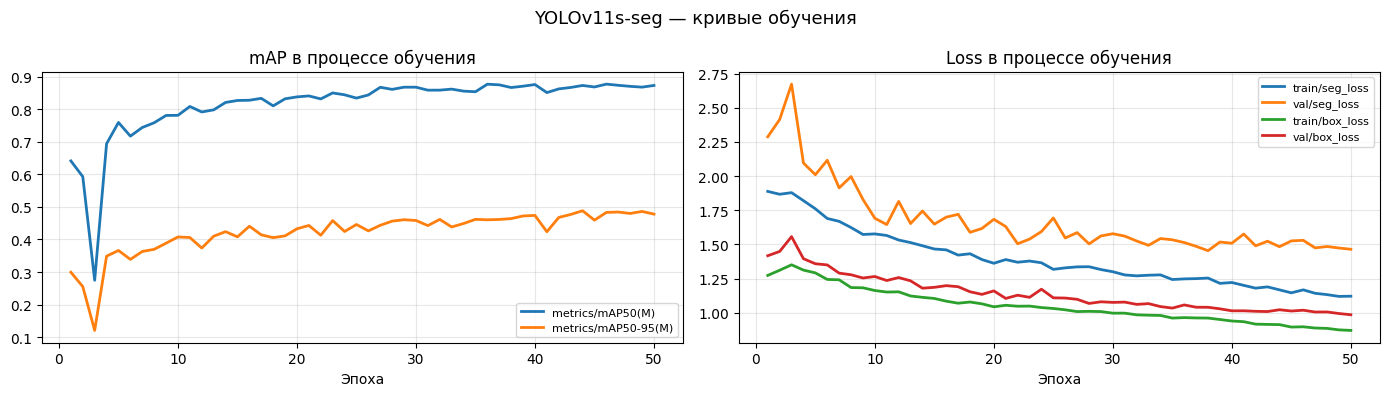

In [8]:
results_csv = CFG.fit_project / "sign_detector" / "results.csv"
if results_csv.exists():
    df_train = pd.read_csv(results_csv)
    df_train.columns = df_train.columns.str.strip()

    available_metrics = [c for c in ["metrics/mAP50(M)", "metrics/mAP50-95(M)"] if c in df_train.columns]
    available_losses  = [c for c in ["train/seg_loss", "val/seg_loss", "train/box_loss", "val/box_loss"] if c in df_train.columns]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if available_metrics:
        for col in available_metrics:
            axes[0].plot(df_train["epoch"], df_train[col], lw=2, label=col)
        axes[0].set_xlabel("Эпоха")
        axes[0].set_title("mAP в процессе обучения")
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.3)
    if available_losses:
        for col in available_losses:
            axes[1].plot(df_train["epoch"], df_train[col], lw=2, label=col)
        axes[1].set_xlabel("Эпоха")
        axes[1].set_title("Loss в процессе обучения")
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3)

    fig.suptitle("YOLOv11s-seg — кривые обучения", fontsize=13)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print("results.csv не найден.")

### Официальные метрики val (mAP)


In [12]:
official_val = NET.val(
    data=str(CFG.yaml_spec),
    split="val",
    imgsz=CFG.img_side,
    batch=CFG.mini_batch,
    device=COMPUTE,
    conf=CFG.score_cutoff,
    iou=CFG.match_iou,
    verbose=False,
)
seg_scores = official_val.seg
print("mAP50:", round(seg_scores.map50, 4))
print("mAP50-95:", round(seg_scores.map, 4))
print("precision:", round(seg_scores.mp, 4), "recall:", round(seg_scores.mr, 4))


Ultralytics 8.4.33  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 882.7229.1 MB/s, size: 103.5 KB)
val: Scanning C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\data\yolo_seg_ready\labels\val... 127 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 2.2Kit/s 0.1s
val: New cache created: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\data\yolo_seg_ready\labels\val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.6it/s 3.0s0.2ss
                   all        127        400      0.911       0.82      0.891      0.692        0.9      0.775      0.866      0.522
Speed: 2.0ms preprocess, 12.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\runs\segment\val4
mAP50: 0.866
mAP50-95: 0.5216
precision: 0.8998 recall: 0.775


### Покадровый разбор масок


In [10]:
def rasterize_label_file(label_path: Path, height: int, width: int) -> list[np.ndarray]:
    if not label_path.exists():
        return []
    layers = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        chunks = line.split()
        if len(chunks) < 7:
            continue
        xy = np.array(chunks[1:], dtype=float).reshape(-1, 2)
        pts = (xy * np.array([width, height])).round().astype(np.int32)
        canvas = np.zeros((height, width), np.uint8)
        cv2.fillPoly(canvas, [pts], 1)
        layers.append(canvas)
    return layers


def overlap_coeff(a: np.ndarray, b: np.ndarray) -> float:
    ab, bb = a.astype(bool), b.astype(bool)
    u = (ab | bb).sum()
    return float((ab & bb).sum()) / float(u + 1e-9)


def mass_center(layer: np.ndarray):
    ys, xs = np.where(layer.astype(bool))
    return (float(xs.mean()), float(ys.mean())) if len(xs) else None


def audit_split(net: YOLO, bundle: Path, part: str = "val", limit: int | None = None) -> pd.DataFrame:
    img_glob = sorted((bundle / "images" / part).glob("*.jpg"))
    if limit and len(img_glob) > limit:
        random.seed(RNG_SEED)
        img_glob = random.sample(img_glob, limit)

    report = []
    for img_path in img_glob:
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue
        h, w = bgr.shape[:2]
        gt_layers = rasterize_label_file(bundle / "labels" / part / f"{img_path.stem}.txt", h, w)

        pred = net.predict(str(img_path), conf=CFG.score_cutoff, device=COMPUTE, verbose=False)[0]
        pred_layers = []
        if pred.masks is not None:
            for tensor in pred.masks.data:
                m = (tensor.cpu().numpy() > 0.5).astype(np.uint8)
                if m.shape != (h, w):
                    m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
                pred_layers.append(m)

        used_p, used_g = set(), set()
        iou_hits, shifts = [], []

        for gi, g_layer in enumerate(gt_layers):
            best, pj = 0.0, -1
            for pi, p_layer in enumerate(pred_layers):
                if pi in used_p:
                    continue
                val = overlap_coeff(p_layer, g_layer)
                if val > best:
                    best, pj = val, pi
            if best >= CFG.match_iou and pj >= 0:
                used_g.add(gi)
                used_p.add(pj)
                iou_hits.append(best)
                c_g, c_p = mass_center(g_layer), mass_center(pred_layers[pj])
                if c_g and c_p:
                    shifts.append(l2_dist(c_g, c_p))

        tp = len(used_g)
        fp = len(pred_layers) - len(used_p)
        fn = len(gt_layers) - tp
        report.append({
            "file": img_path.name,
            "gt": len(gt_layers),
            "pred": len(pred_layers),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "iou": float(np.mean(iou_hits)) if iou_hits else 0.0,
            "prec": tp / (tp + fp + 1e-9),
            "rec": tp / (tp + fn + 1e-9),
            "l2_px": float(np.mean(shifts)) if shifts else np.nan,
        })

    return pd.DataFrame(report)


VAL_AUDIT = audit_split(NET, CFG.seg_bundle, part="val")
VAL_AUDIT.to_csv(CFG.artifact_dir / "val_audit.csv", index=False)

subset = VAL_AUDIT[VAL_AUDIT["gt"] > 0]
print("frames with gt:", len(subset))
print("mean iou:", subset["iou"].mean().round(4))
print("mean prec:", subset["prec"].mean().round(4))
print("mean rec:", subset["rec"].mean().round(4))
for thr in (0.5, 0.75, 0.9):
    pct = 100 * (subset["iou"] >= thr).mean()
    print(f"share iou>={thr}: {pct:.1f}%")


frames with gt: 127
mean iou: 0.6278
mean prec: 0.7621
mean rec: 0.708
share iou>=0.5: 95.3%
share iou>=0.75: 13.4%
share iou>=0.9: 0.8%


### Визуализация val


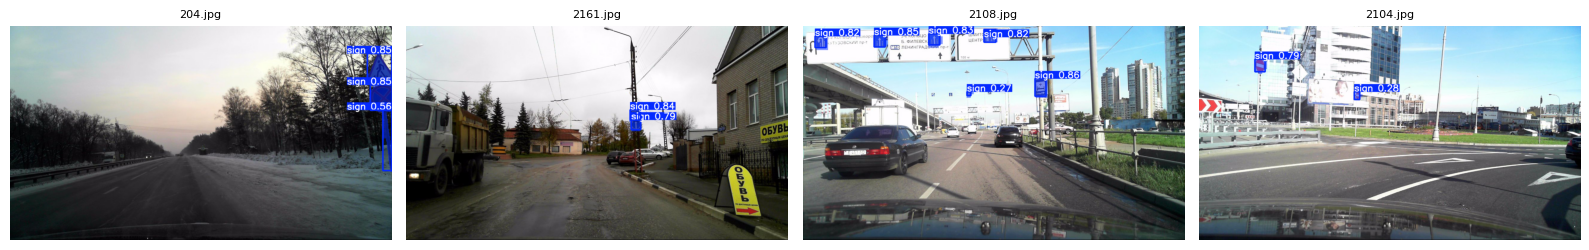

In [11]:
preview_dir = CFG.seg_bundle / "images" / "val"
samples = sorted(preview_dir.glob("*.jpg"))
if samples:
    picks = random.sample(samples, k=min(4, len(samples)))
    fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4))
    if len(picks) == 1:
        axes = [axes]
    for ax, p in zip(axes, picks):
        vis = NET.predict(str(p), conf=CFG.score_cutoff, device=COMPUTE, verbose=False)[0].plot()
        ax.imshow(vis[:, :, ::-1])
        ax.set_title(p.name, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


### Видео и фотографии


In [17]:
clips = sorted(CFG.clip_folder.glob("*.mp4")) + sorted(CFG.clip_folder.glob("*.mov"))
stills = sorted(p for p in CFG.stills_folder.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})

seg_dump = CFG.artifact_dir / "inference"
seg_dump.mkdir(parents=True, exist_ok=True)

for clip in clips:
    out_mp4 = seg_dump / f"{clip.stem}_masks.mp4"
    cap = cv2.VideoCapture(str(clip))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = cv2.VideoWriter(str(out_mp4), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        painted = NET.predict(frame, conf=CFG.score_cutoff, device=COMPUTE, imgsz=CFG.img_side, verbose=False)[0].plot()
        writer.write(painted)
    cap.release()
    writer.release()
    print("video saved:", out_mp4)

if stills:
    photo_results = NET.predict(
        source=[str(s) for s in stills],
        conf=CFG.score_cutoff,
        imgsz=CFG.img_side,
        save=True,
        project=str(seg_dump),
        name="stills",
        exist_ok=True,
        device=COMPUTE,
        verbose=False,
    )
    print("photos ->", seg_dump / "stills")
else:
    print("no photos in", CFG.stills_folder)


video saved: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\outputs\inference\1_masks.mp4
video saved: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\outputs\inference\2_masks.mp4
video saved: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\outputs\inference\3_masks.mp4
Results saved to C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\outputs\inference\stills
photos -> C:\Users\Daria\Desktop\ITMO\cv-itmo\lab3\outputs\inference\stills


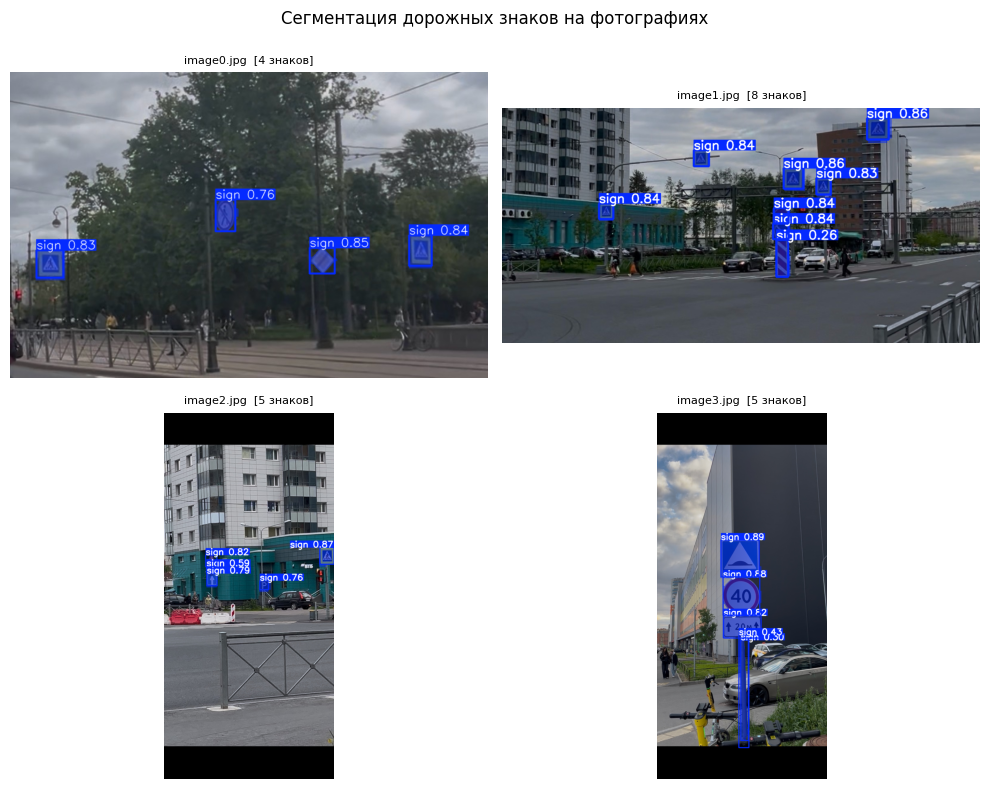

In [18]:
n    = len(photo_results)
cols = min(2, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = np.array(axes).flatten()

for ax, res in zip(axes, photo_results):
    annotated = res.plot()
    ax.imshow(annotated[:, :, ::-1])
    n_det = len(res.boxes) if res.boxes is not None else 0
    ax.set_title(f"{Path(res.path).name}  [{n_det} знаков]", fontsize=8)
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Сегментация дорожных знаков на фотографиях", fontsize=12)
plt.tight_layout()
plt.show()

### Multi-object tracking + ID switches


In [21]:
def track_clip(net: YOLO, clip_path: Path, backend: str, conf: float = 0.4) -> list[dict]:
    capture = cv2.VideoCapture(str(clip_path))
    timeline: list[dict] = []
    frame_no = 0
    while True:
        ok, frame = capture.read()
        if not ok:
            break
        packet = net.track(
            frame,
            conf=conf,
            tracker=f"{backend}.yaml",
            persist=True,
            verbose=False,
            device=COMPUTE,
            imgsz=CFG.img_side,
        )[0]
        ids, boxes = [], []
        if packet.boxes is not None and packet.boxes.id is not None:
            ids = packet.boxes.id.cpu().numpy().astype(int).tolist()
            boxes = packet.boxes.xyxy.cpu().numpy().tolist()
        timeline.append({"t": frame_no, "ids": ids, "boxes": boxes})
        frame_no += 1
    capture.release()
    return timeline


def estimate_identity_flips(timeline: list[dict], iou_gate: float = 0.3, gap: int = 5) -> int:
    memory: dict[int, dict] = {}
    alive: dict[int, int] = {}
    flips = 0

    for frame in timeline:
        t = frame["t"]
        present = set(frame["ids"])
        vanished = set(alive) - present
        appeared = present - set(alive)

        if vanished and appeared:
            newcomers = {i: frame["boxes"][k] for k, i in enumerate(frame["ids"]) if i in appeared}
            for old_id in vanished:
                snap = memory.get(old_id)
                if not snap or t - snap["t"] > gap:
                    continue
                for _, box in newcomers.items():
                    if _rect_iou(snap["box"], box) >= iou_gate:
                        flips += 1
                        break

        for i, box in zip(frame["ids"], frame["boxes"]):
            memory[i] = {"t": t, "box": box}
        alive = {i: t for i in present}

    return flips


def _rect_iou(a: list, b: list) -> float:
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    inter = (x2 - x1) * (y2 - y1)
    aa = (a[2] - a[0]) * (a[3] - a[1])
    bb = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (aa + bb - inter + 1e-9)


track_rows = []
for clip in clips:
    for engine in ("bytetrack", "botsort"):
        seq = track_clip(NET, clip, engine)
        flips = estimate_identity_flips(seq)
        track_rows.append({"clip": clip.name, "engine": engine, "id_flips": flips, "frames": len(seq), "timeline": seq})
        print(clip.name, engine, "flips=", flips)

if track_rows:
    pd.DataFrame(track_rows).to_csv(CFG.artifact_dir / "tracking_report.csv", index=False)


1.mp4 bytetrack flips= 0
1.mp4 botsort flips= 0
2.mp4 bytetrack flips= 1
2.mp4 botsort flips= 1
3.mp4 bytetrack flips= 4
3.mp4 botsort flips= 4


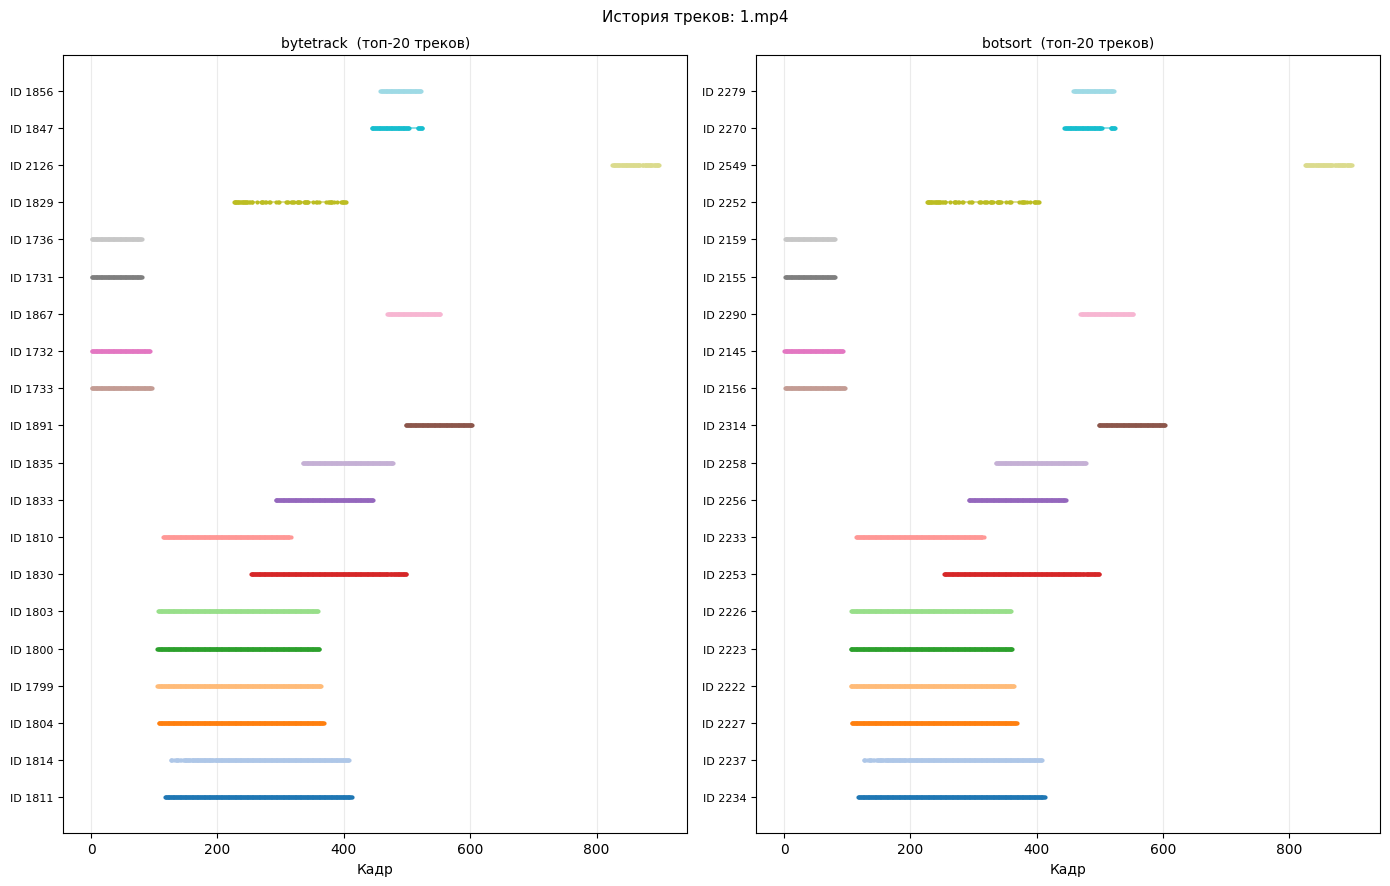

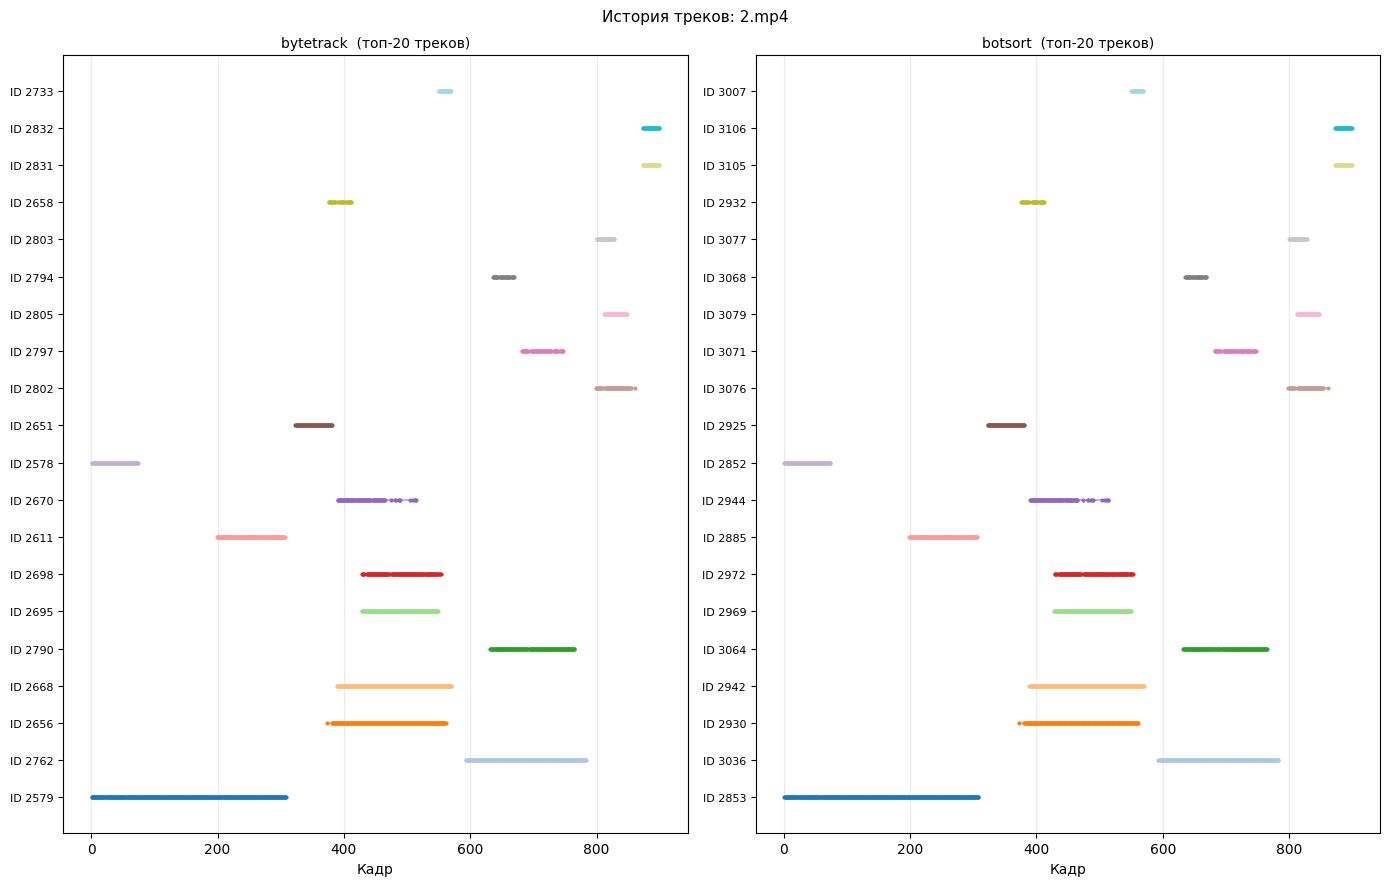

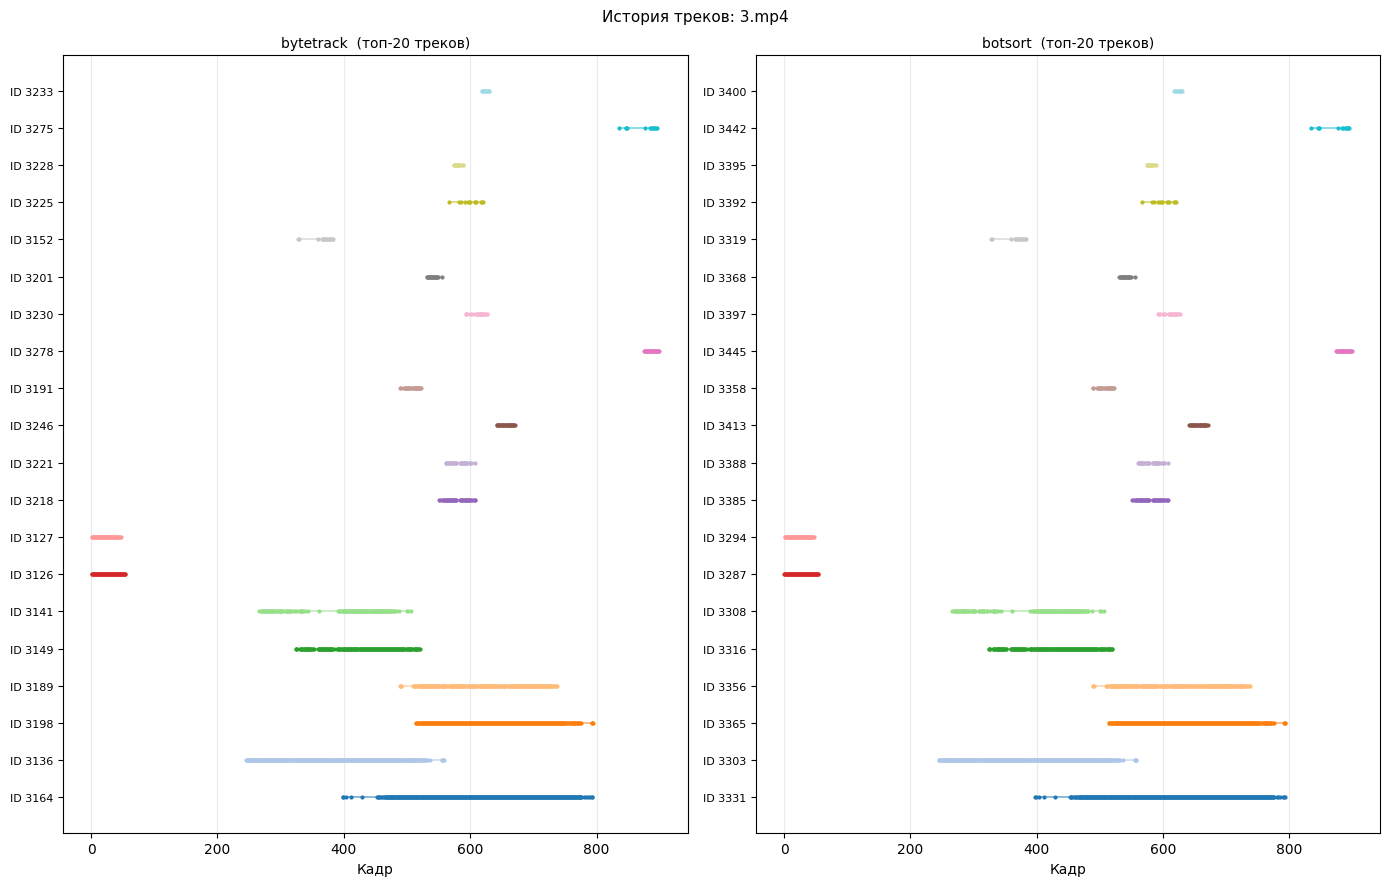

In [23]:
import matplotlib.pyplot as plt
from collections import defaultdict

def _timeline_to_records(seq: list[dict]) -> list[dict]:
    """Ваш формат {t, ids, boxes} -> формат графика {frame_idx, track_ids}."""
    return [
        {"frame_idx": fr["t"], "track_ids": fr["ids"]}
        for fr in seq
    ]

def tracking_by_clip(track_rows: list[dict], clip_name: str) -> dict[str, list[dict]]:
    """{engine: timeline} для одного видео."""
    out = {}
    for row in track_rows:
        if row["clip"] != clip_name:
            continue
        if "timeline" not in row:
            raise KeyError(
                f"В track_rows нет 'timeline' для {clip_name}. "
                "Добавьте timeline при track_rows.append(...)."
            )
        out[row["engine"]] = _timeline_to_records(row["timeline"])
    return out

def plot_track_comparison(tracking_by_tracker: dict, video_name: str, max_tracks: int = 20, max_frames: int = 900):
    tracker_names = list(tracking_by_tracker.keys())
    n = len(tracker_names)

    fig, axes = plt.subplots(1, n, figsize=(7 * n, max(4, max_tracks * 0.45)), sharey=False)
    if n == 1:
        axes = [axes]
    cmap = plt.get_cmap("tab20")

    for ax, tname in zip(axes, tracker_names):
        records = tracking_by_tracker[tname]
        track_frames = defaultdict(list)
        for rec in records[:max_frames]:
            for tid in rec["track_ids"]:
                track_frames[tid].append(rec["frame_idx"])

        top_ids = sorted(track_frames.keys(), key=lambda t: -len(track_frames[t]))[:max_tracks]
        for yi, tid in enumerate(top_ids):
            frames = track_frames[tid]
            color = cmap(yi % 20)
            ax.scatter(frames, [yi] * len(frames), s=4, color=color, zorder=2)
            if len(frames) > 1:
                ax.plot(frames, [yi] * len(frames), color=color, lw=1.2, alpha=0.6)
        ax.set_yticks(range(len(top_ids)))
        ax.set_yticklabels([f"ID {t}" for t in top_ids], fontsize=8)
        ax.set_xlabel("Кадр")
        ax.set_title(f"{tname}  (топ-{len(top_ids)} треков)", fontsize=10)
        ax.grid(True, alpha=0.25, axis="x")

    plt.suptitle(f"История треков: {video_name[:35]}", fontsize=11)
    plt.tight_layout()
    plt.show()


# все клипы
for clip_name in sorted({r["clip"] for r in track_rows}):
    plot_track_comparison(tracking_by_clip(track_rows, clip_name), clip_name)